In [11]:
# Libraries

import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
from urllib.parse import urlparse
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import warnings
warnings.filterwarnings('ignore')

In [12]:
# Loading data and Info

df = pd.read_csv('data/malicious_phish.csv')
print(df.head())
print("\nData Info:")
print(df.info())
print("\nUnique labels:", df['type'].unique())

                                                 url        type
0                                   br-icloud.com.br    phishing
1                mp3raid.com/music/krizz_kaliko.html      benign
2                    bopsecrets.org/rexroth/cr/1.htm      benign
3  http://www.garage-pirenne.be/index.php?option=...  defacement
4  http://adventure-nicaragua.net/index.php?optio...  defacement

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 651191 entries, 0 to 651190
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   url     651191 non-null  object
 1   type    651191 non-null  object
dtypes: object(2)
memory usage: 9.9+ MB
None

Unique labels: ['phishing' 'benign' 'defacement' 'malware']


In [13]:
# Checking Missing value
  
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 url     0
type    0
dtype: int64


In [14]:
# Label Encoding

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['type'])
print("\nEncoded labels mapping:")
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))



Encoded labels mapping:
{'benign': np.int64(0), 'defacement': np.int64(1), 'malware': np.int64(2), 'phishing': np.int64(3)}


In [15]:
# Feature Engineeing Function

def count_dots(url):
    return url.count('.')

def count_hyphens(url):
    return url.count('-')

def count_at(url):
    return url.count('@')

def count_question(url):
    return url.count('?')

def count_equal(url):
    return url.count('=')

def count_digits(url):
    return sum(c.isdigit() for c in url)

def url_length(url):
    return len(url)

def hostname_length(url):
    try:
        return len(urlparse(url).netloc)
    except:
        return 0

def path_length(url):
    try:
        return len(urlparse(url).path)
    except:
        return 0

def count_https(url):
    return 1 if 'https' in url else 0

def count_http(url):
    return 1 if 'http' in url else 0

def suspicious_words(url):
    suspicious = ['login', 'signin', 'bank', 'update', 'free', 'bonus', 'secure', 'account', 'confirm']
    return sum(word in url.lower() for word in suspicious)


In [16]:
# Feature Function

df['url_length'] = df['url'].apply(url_length)
df['hostname_length'] = df['url'].apply(hostname_length)
df['path_length'] = df['url'].apply(path_length)
df['count-'] = df['url'].apply(count_hyphens)
df['count@'] = df['url'].apply(count_at)
df['count?'] = df['url'].apply(count_question)
df['count='] = df['url'].apply(count_equal)
df['count.'] = df['url'].apply(count_dots)
df['count_digits'] = df['url'].apply(count_digits)
df['count_https'] = df['url'].apply(count_https)
df['count_http'] = df['url'].apply(count_http)
df['suspicious_words'] = df['url'].apply(suspicious_words)


In [17]:
# Train test split the data 


X = df[['url_length','hostname_length','path_length','count-','count@','count?','count=','count.','count_digits','count_https','count_http','suspicious_words']]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTraining data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)


Training data shape: (520952, 12)
Testing data shape: (130239, 12)


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
# Evaluation

y_pred = rf.predict(X_test)

print("\n🎯 Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


🎯 Model Performance:
Accuracy: 0.8954153517763497

Classification Report:
               precision    recall  f1-score   support

      benign       0.90      0.97      0.93     85621
  defacement       0.95      0.97      0.96     19292
     malware       0.97      0.92      0.95      6504
    phishing       0.74      0.47      0.58     18822

    accuracy                           0.90    130239
   macro avg       0.89      0.83      0.85    130239
weighted avg       0.89      0.90      0.89    130239


Confusion Matrix:
 [[83030    48    20  2523]
 [   93 18789    57   353]
 [  240   143  5975   146]
 [ 9157   758    83  8824]]


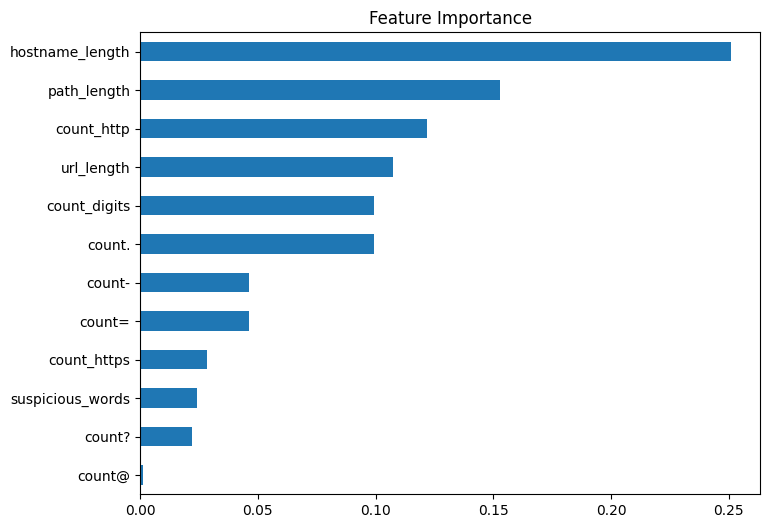


✅ Model and encoder saved successfully!


In [19]:
# FEATURE IMPORTANCE

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8,6), title='Feature Importance')
plt.show()

# SAVE MODEL
joblib.dump(rf, 'phishing_url_detector.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')

print("\n✅ Model and encoder saved successfully!")

In [20]:
# TEST ON SAMPLE URL

sample = {
    'url': ['http://freebonus-login-secure-account.com']
}

sample_df = pd.DataFrame(sample)
sample_df['url_length'] = sample_df['url'].apply(url_length)
sample_df['hostname_length'] = sample_df['url'].apply(hostname_length)
sample_df['path_length'] = sample_df['url'].apply(path_length)
sample_df['count-'] = sample_df['url'].apply(count_hyphens)
sample_df['count@'] = sample_df['url'].apply(count_at)
sample_df['count?'] = sample_df['url'].apply(count_question)
sample_df['count='] = sample_df['url'].apply(count_equal)
sample_df['count.'] = sample_df['url'].apply(count_dots)
sample_df['count_digits'] = sample_df['url'].apply(count_digits)
sample_df['count_https'] = sample_df['url'].apply(count_https)
sample_df['count_http'] = sample_df['url'].apply(count_http)
sample_df['suspicious_words'] = sample_df['url'].apply(suspicious_words)

# Predict
pred = rf.predict(sample_df.drop('url', axis=1))[0]
label = label_encoder.inverse_transform([pred])[0]

print(f"\n🔎 Predicted Type for '{sample_df['url'][0]}': {label}")


🔎 Predicted Type for 'http://freebonus-login-secure-account.com': phishing
